1. IMPORT DAN SETUP

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = '/content/drive/MyDrive/dataset/dataset'

2. Load Dataset

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128,128)
BATCH = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH + '/train',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH + '/test',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical'
)

num_classes = train_generator.num_classes
print("Jumlah kelas:", num_classes)

Found 8497 images belonging to 6 classes.
Found 2695 images belonging to 6 classes.
Jumlah kelas: 6


In [ ]:
num_classes = 6

3. MODEL CNN SEDERHANA (SEBELUM OPTIMASI)

Found 8497 images belonging to 6 classes.
Found 2695 images belonging to 6 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.7264 - loss: 0.7478 - val_accuracy: 0.8568 - val_loss: 0.4186
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.8753 - loss: 0.3871 - val_accuracy: 0.8731 - val_loss: 0.3644
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.8927 - loss: 0.3208 - val_accuracy: 0.8746 - val_loss: 0.3881
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.9028 - loss: 0.2894 - val_accuracy: 0.8961 - val_loss: 0.2998
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.9174 - loss: 0.2618 - val_accuracy: 0.9199 - val_loss: 0.2247
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.9315 - loss: 0.2174 - val_accuracy: 0.9017 - val_loss: 0.2660
Epoch 7/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.9301 - loss: 0.2108 - val_accuracy: 0.9436 - val_loss: 0.1561
Epoch 8/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.9422 - loss: 0.1726 - val_accu

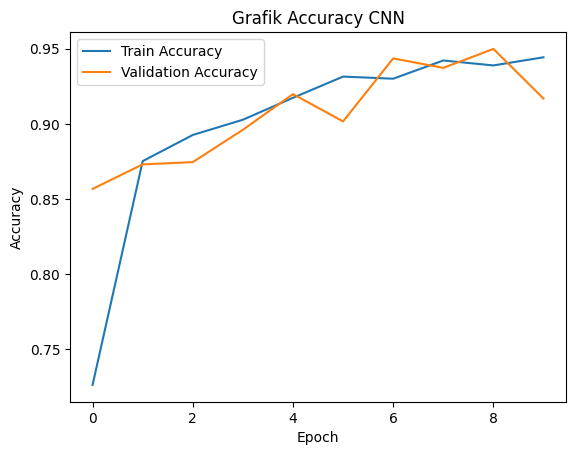

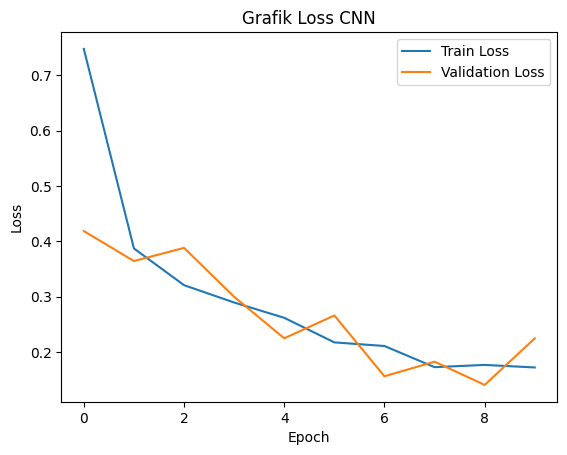

In [ ]:
# ======================
# IMPORT
# ======================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ======================
# PATH DATASET (SESUAIKAN)
# ======================
train_dir = DATASET_PATH + "/train"
val_dir   = DATASET_PATH + "/test"

IMG_SIZE = (128,128)
BATCH_SIZE = 32

# ======================
# DATA GENERATOR
# ======================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ======================
# MODEL CNN (BERSIH & STABIL)
# ======================
model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ======================
# TRAINING
# ======================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ======================
# SAVE MODEL
# ======================
model.save("model_cnn.h5")

# ======================
# GRAFIK ACCURACY
# ======================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Accuracy CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ======================
# GRAFIK LOSS
# ======================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=1,
    min_lr=1e-6
)

In [ ]:
from PIL import Image
import os

def clean_dataset(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()  # cek validitas
            except:
                print("Hapus file rusak:", path)
                os.remove(path)

# jalankan
clean_dataset('/content/drive/MyDrive/dataset/dataset/train')
clean_dataset('/content/drive/MyDrive/dataset/dataset/test')

5. MODEL 2 — Build MobileNetV2 (TRANSFER LEARNING)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

# freeze biar cepat
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation='softmax')
])

6. compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

7. GRAFIK

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 274s 1000ms/step - accuracy: 0.9073 - loss: 0.2943 - val_accuracy: 0.9547 - val_loss: 0.1328
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 308s 949ms/step - accuracy: 0.9712 - loss: 0.0950 - val_accuracy: 0.9640 - val_loss: 0.1009
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.9829 - loss: 0.0649 - val_accuracy: 0.9696 - val_loss: 0.0860
Epoch 4/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 253s 952ms/step - accuracy: 0.9856 - loss: 0.0492 - val_accuracy: 0.9740 - val_loss: 0.0731
Epoch 5/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.9883 - loss: 0.0404 - val_accuracy: 0.9777 - val_loss: 0.0579
Epoch 6/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 253s 949ms/step - accuracy: 0.9915 - loss: 0.0337 - val_accuracy: 0.9844 - val_loss: 0.0436
Epoch 7/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 260s 976ms/step - accuracy: 0.9935 - loss: 0.0269 - val_accuracy: 0.9840 - val_loss: 0.0402
Epoch 8/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 263s 989ms/step - accuracy: 0.9940 - loss

8. Fine-Tuning RINGAN

In [ ]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.9573 - loss: 0.1433 - val_accuracy: 0.9703 - val_loss: 0.0953
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.9907 - loss: 0.0266 - val_accuracy: 0.9777 - val_loss: 0.0714
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.9938 - loss: 0.0191 - val_accuracy: 0.9852 - val_loss: 0.0453


8. evaluasi

In [ ]:
loss, acc = model.evaluate(val_generator)
print("Accuracy:", acc)

85/85 ━━━━━━━━━━━━━━━━━━━━ 51s 600ms/step - accuracy: 0.9852 - loss: 0.0453
Accuracy: 0.9851577281951904


9. grafik

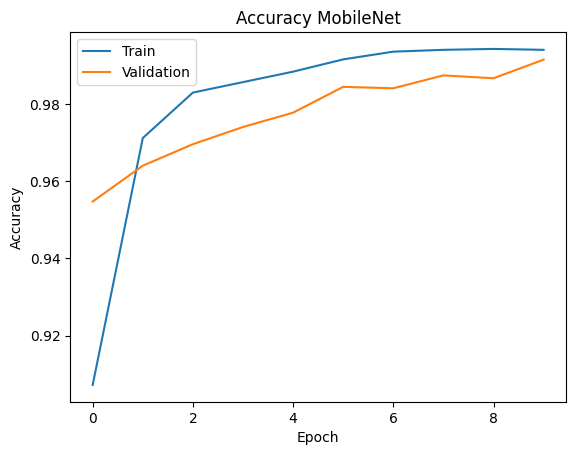

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title('Accuracy MobileNet')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

10.simpan model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.save("model_baru.h5")

In [ ]:
import os
print(os.listdir())

['.config', 'model_cnn.h5', '.ipynb_checkpoints', 'model_baru.h5', 'istockphoto-184276818-612x612.jpg', 'drive', 'sample_data']


In [ ]:
from google.colab import files
files.download("model_baru.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_generator, epochs=2)

Epoch 1/2
266/266 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.7830 - loss: 0.6165
Epoch 2/2
266/266 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.8981 - loss: 0.2941


In [ ]:
model.save("model_baru.h5")

In [ ]:
from google.colab import files
files.download("model_baru.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

11.simpan label

In [ ]:
import json

with open('/content/drive/MyDrive/class_indices.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

In [ ]:
import json

with open('/content/drive/MyDrive/class_indices.json', 'w') as f:
    json.dump(train_generator.class_indices, f)

print("✅ class_indices.json berhasil dibuat")

✅ class_indices.json berhasil dibuat


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/class_indices.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit

Streamlit (app.py)

In [ ]:
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
import json
import os

# ================================
# CONFIG
# ================================
MODEL_PATH = "model_mobilenet.keras"
LABEL_PATH = "class_indices.json"
IMG_SIZE = (128,128)

# ================================
# LOAD MODEL (AMAN)
# ================================
@st.cache_resource
def load_model_safe():
    if not os.path.exists(MODEL_PATH):
        st.error("❌ Model tidak ditemukan!")
        return None
    return tf.keras.models.load_model(MODEL_PATH)

model = load_model_safe()

# ================================
# LOAD LABEL (AMAN)
# ================================
def load_labels_safe():
    if not os.path.exists(LABEL_PATH):
        st.error("❌ class_indices.json tidak ditemukan!")
        return None
    with open(LABEL_PATH, "r") as f:
        return json.load(f)

class_idx = load_labels_safe()

if class_idx:
    idx_to_class = {v:k for k,v in class_idx.items()}
else:
    idx_to_class = None

# ================================
# UI
# ================================
st.title("🍎 Klasifikasi Buah (MobileNetV2)")
st.write("Upload gambar buah untuk diprediksi")

uploaded_file = st.file_uploader("Upload gambar", type=["jpg","jpeg","png"])

# ================================
# PREDIKSI
# ================================
if uploaded_file is not None and model is not None and idx_to_class is not None:
    try:
        # tampilkan gambar
        image = Image.open(uploaded_file).convert("RGB")
        st.image(image, caption="Gambar yang diupload", use_container_width=True)

        # preprocessing
        img = image.resize(IMG_SIZE)
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # prediksi
        preds = model.predict(img_array)[0]

        # top 3
        top3 = preds.argsort()[-3:][::-1]

        st.subheader("📊 Hasil Prediksi:")

        for i in top3:
            st.write(f"{idx_to_class[i]} : {preds[i]*100:.2f}%")

        st.success("✅ Prediksi berhasil!")

    except Exception as e:
        st.error(f"Terjadi error saat prediksi: {e}")

2026-04-26 12:38:39.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.805 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.810 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-26 12:38:39.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
import json

model = tf.keras.models.load_model("/content/drive/MyDrive/model_mobilenet.keras")

with open("/content/drive/MyDrive/class_indices.json","r") as f:
    class_idx = json.load(f)

idx_to_class = {v:k for k,v in class_idx.items()}

st.title("Klasifikasi Buah (MobileNetV2)")

file = st.file_uploader("Upload gambar", type=["jpg","png","jpeg"])

if file:
    img = Image.open(file).convert("RGB")
    st.image(img, caption="Gambar", use_container_width=True)

    img = img.resize((128,128))
    x = np.array(img)/255.0
    x = np.expand_dims(x, axis=0)

    preds = model.predict(x)[0]
    top3 = preds.argsort()[-3:][::-1]

    st.subheader("Top-3 Prediction:")
    for i in top3:
        st.write(f"{idx_to_class[i]} : {preds[i]*100:.2f}%")

!streamlit run app.py

Overwriting app.py


In [6]:
from google.colab import files
files.download("nama_file.ipynb")

FileNotFoundError: Cannot find file: nama_file.ipynb